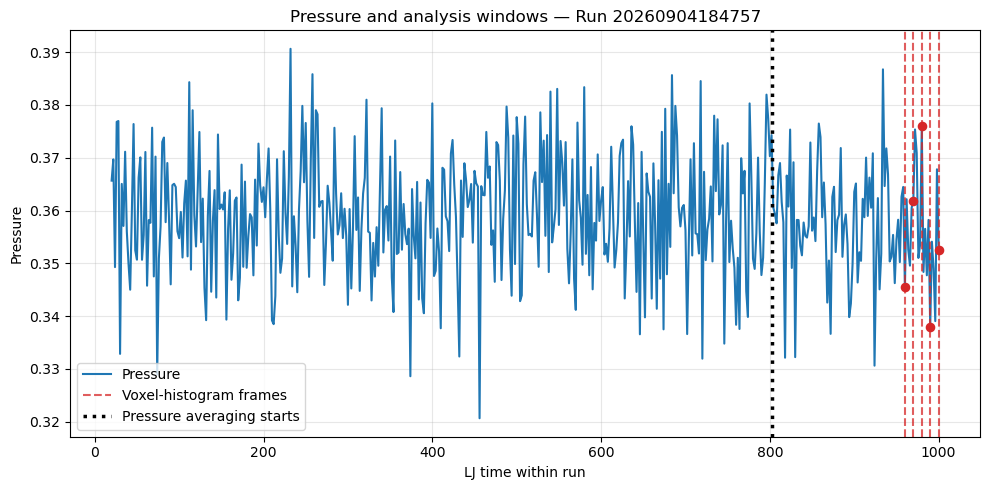

In [5]:
import matplotlib.pyplot as plt

from md_Helpers import open_run
from md_Helpers.voxel_fit import phase_fit_frame_indices


# --------------------------------------------------
# Choose the run
# --------------------------------------------------
RUN_ID = "20260904184757"


run = open_run(RUN_ID)
logs = run.logs_dataframe()

# Frames used for the averaged voxel histogram:
# -1, -6, -11, -16, and -21 when available.
voxel_frame_ids = phase_fit_frame_indices(len(logs))
voxel_samples = logs.iloc[voxel_frame_ids]

# Locate the beginning of the SQL pressure-summary window.
summary_start_step = int(run.state_row["Summary_Start_Step"])
summary_start_rows = logs[logs["run_step"] >= summary_start_step]

if summary_start_rows.empty:
    raise ValueError(
        f"Summary_Start_Step {summary_start_step} was not found in the logs."
    )

summary_start_time = summary_start_rows.iloc[0]["this_lj_time"]

# Skip the first 10 plotted samples for fresh lattice runs.
plot_logs = logs.iloc[10:] if run.started_from_lattice else logs

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    plot_logs["this_lj_time"],
    plot_logs["pressure"],
    color="C0",
    linewidth=1.5,
    label="Pressure",
)

# Voxel-histogram sampling times.
for index, (frame_id, sample) in enumerate(
    zip(voxel_frame_ids, voxel_samples.itertuples())
):
    ax.axvline(
        sample.this_lj_time,
        color="C3",
        linestyle="--",
        alpha=0.75,
        label="Voxel-histogram frames" if index == 0 else None,
    )
    ax.scatter(
        sample.this_lj_time,
        sample.pressure,
        color="C3",
        s=35,
        zorder=3,
    )

# Beginning of pressure averaging.
ax.axvline(
    summary_start_time,
    color="black",
    linestyle=":",
    linewidth=2.5,
    label="Pressure averaging starts",
)

ax.set_xlabel("LJ time within run")
ax.set_ylabel("Pressure")
ax.set_title(f"Pressure and analysis windows — Run {RUN_ID}")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

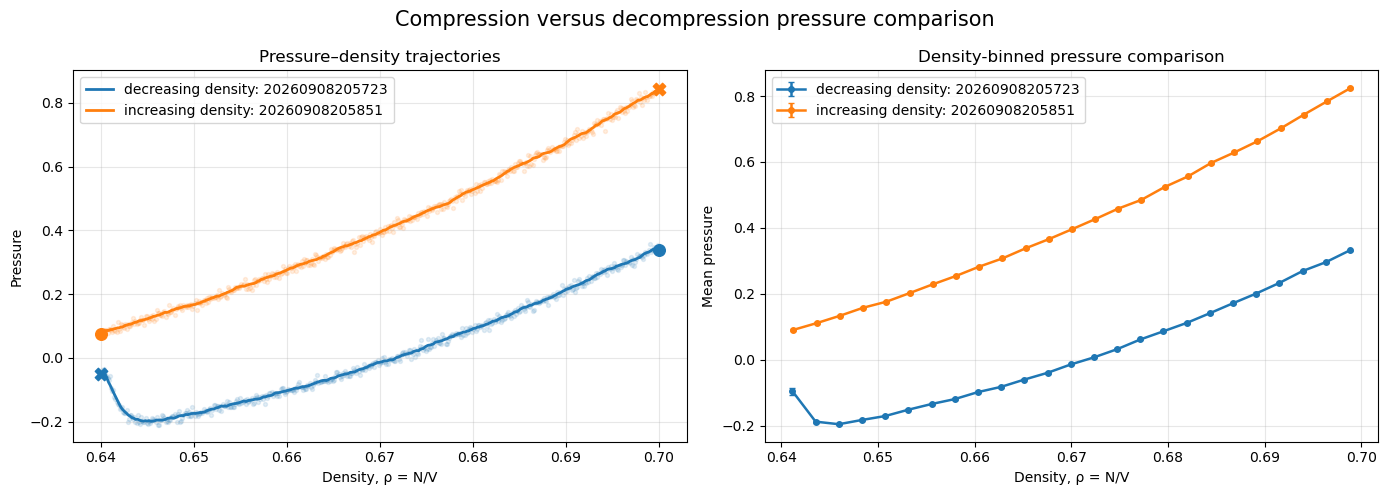

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from md_Helpers import open_run

# Replace these if you want to compare different runs.
run_ids = [
    "20260908205723",
    "20260908205851",
]

SMOOTH_POINTS = 15
N_DENSITY_BINS = 25

runs = {}

for run_id in run_ids:
    logs = open_run(run_id).logs_dataframe()

    data = (
        logs[["density", "pressure"]]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .reset_index(drop=True)
    )

    direction = (
        "increasing density"
        if data["density"].iloc[-1] > data["density"].iloc[0]
        else "decreasing density"
    )

    runs[run_id] = {
        "data": data,
        "direction": direction,
    }

# Use the same density bins for both runs.
all_density = pd.concat(
    [item["data"]["density"] for item in runs.values()],
    ignore_index=True,
)

bin_edges = np.linspace(
    all_density.min(),
    all_density.max(),
    N_DENSITY_BINS + 1,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---------------------------------------------------------
# Left: pressure trajectory as density changes
# ---------------------------------------------------------
for run_id, item in runs.items():
    data = item["data"]
    direction = item["direction"]

    smooth = data[["density", "pressure"]].rolling(
        SMOOTH_POINTS,
        center=True,
        min_periods=1,
    ).mean()

    line, = axes[0].plot(
        smooth["density"],
        smooth["pressure"],
        linewidth=2,
        label=f"{direction}: {run_id}",
    )

    color = line.get_color()

    # Faint unsmoothed measurements
    axes[0].scatter(
        data["density"],
        data["pressure"],
        color=color,
        s=8,
        alpha=0.12,
    )

    # Mark where each run begins and ends
    axes[0].scatter(
        data["density"].iloc[0],
        data["pressure"].iloc[0],
        color=color,
        marker="o",
        s=70,
        zorder=5,
    )
    axes[0].scatter(
        data["density"].iloc[-1],
        data["pressure"].iloc[-1],
        color=color,
        marker="X",
        s=80,
        zorder=5,
    )

axes[0].set_xlabel("Density, ρ = N/V")
axes[0].set_ylabel("Pressure")
axes[0].set_title("Pressure–density trajectories")
axes[0].grid(alpha=0.3)
axes[0].legend()

# ---------------------------------------------------------
# Right: pressure averaged within density bins
# ---------------------------------------------------------
for run_id, item in runs.items():
    data = item["data"].copy()
    direction = item["direction"]

    data["density_bin"] = pd.cut(
        data["density"],
        bins=bin_edges,
        include_lowest=True,
    )

    summary = (
        data.groupby("density_bin", observed=True)
        .agg(
            density=("density", "mean"),
            pressure=("pressure", "mean"),
            pressure_std=("pressure", "std"),
            samples=("pressure", "size"),
        )
        .reset_index(drop=True)
    )

    summary["pressure_sem"] = (
        summary["pressure_std"] / np.sqrt(summary["samples"])
    )

    axes[1].errorbar(
        summary["density"],
        summary["pressure"],
        yerr=summary["pressure_sem"],
        marker="o",
        markersize=4,
        linewidth=1.8,
        capsize=2,
        label=f"{direction}: {run_id}",
    )

axes[1].set_xlabel("Density, ρ = N/V")
axes[1].set_ylabel("Mean pressure")
axes[1].set_title("Density-binned pressure comparison")
axes[1].grid(alpha=0.3)
axes[1].legend()

fig.suptitle(
    "Compression versus decompression pressure comparison",
    fontsize=15,
)

fig.tight_layout()
plt.show()

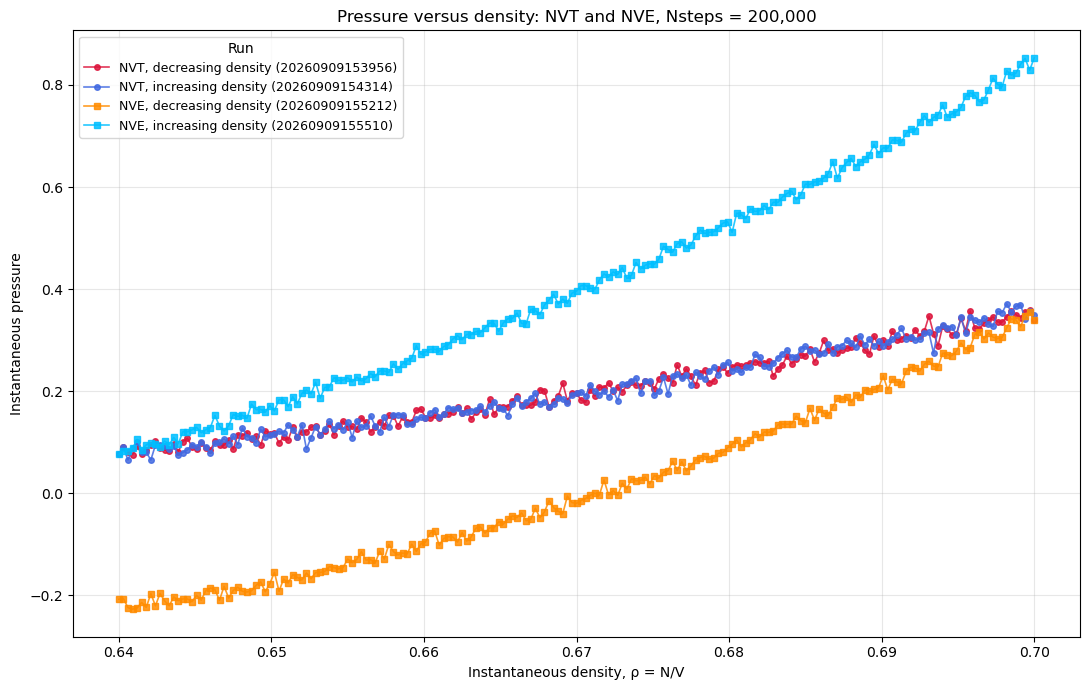

In [10]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from md_Helpers import open_run

runs = {
    "NVT": [
        "20260909153956",
        "20260909154314",
    ],
    "NVE": [
        "20260909155212",
        "20260909155510",
    ],
}

ensemble_markers = {
    "NVT": "o",
    "NVE": "s",
}

# A distinct color for every ensemble–direction combination
colors = {
    ("NVT", "increasing density"): "royalblue",
    ("NVT", "decreasing density"): "crimson",
    ("NVE", "increasing density"): "deepskyblue",
    ("NVE", "decreasing density"): "darkorange",
}

fig, ax = plt.subplots(figsize=(11, 7))

for ensemble, run_ids in runs.items():
    for run_id in run_ids:
        logs = open_run(run_id).logs_dataframe()

        density = logs["num_particles"] / logs["volume"]
        pressure = logs["pressure"]

        direction = (
            "increasing density"
            if density.iloc[-1] > density.iloc[0]
            else "decreasing density"
        )

        ax.plot(
            density,
            pressure,
            color=colors[(ensemble, direction)],
            marker=ensemble_markers[ensemble],
            markersize=4,
            linewidth=1.2,
            alpha=0.85,
            label=f"{ensemble}, {direction} ({run_id})",
        )

ax.set_xlabel("Instantaneous density, ρ = N/V")
ax.set_ylabel("Instantaneous pressure")
ax.set_title("Pressure versus density: NVT and NVE, Nsteps = 200,000")
ax.grid(alpha=0.3)
ax.legend(title="Run", fontsize=9)

plt.tight_layout()
plt.show()

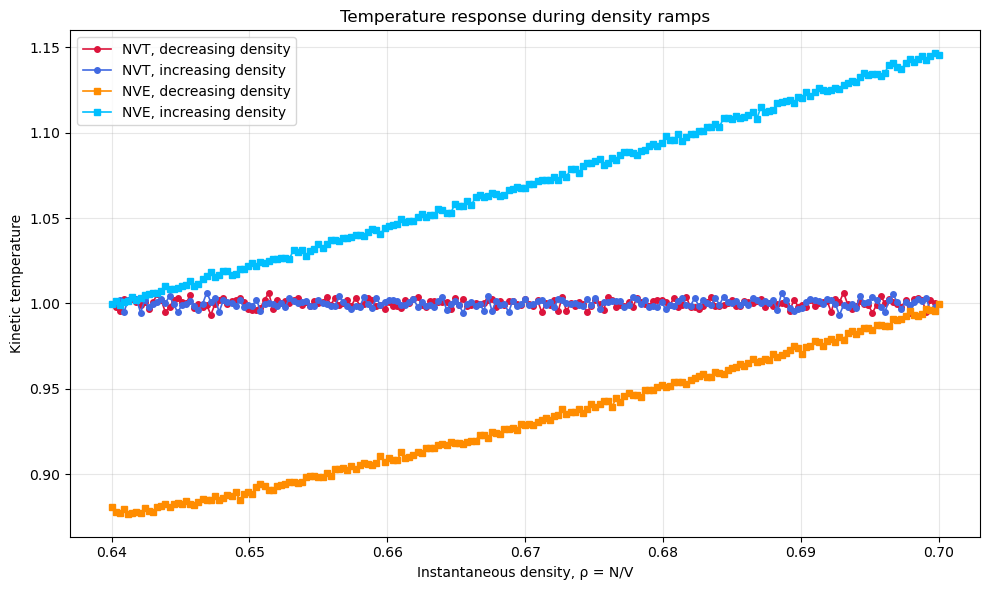

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

for ensemble, run_ids in runs.items():
    for run_id in run_ids:
        logs = open_run(run_id).logs_dataframe()

        density = logs["num_particles"] / logs["volume"]
        temperature = logs["kinetic_temperature"]

        direction = (
            "increasing density"
            if density.iloc[-1] > density.iloc[0]
            else "decreasing density"
        )

        ax.plot(
            density,
            temperature,
            color=colors[(ensemble, direction)],
            marker=ensemble_markers[ensemble],
            markersize=4,
            linewidth=1.2,
            label=f"{ensemble}, {direction}",
        )

ax.set_xlabel("Instantaneous density, ρ = N/V")
ax.set_ylabel("Kinetic temperature")
ax.set_title("Temperature response during density ramps")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

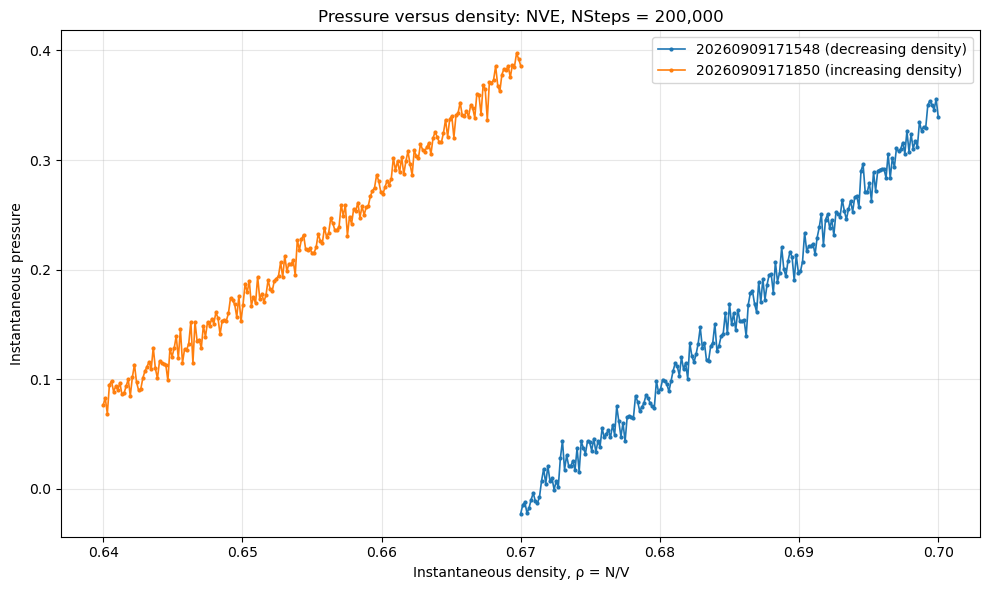

In [16]:
import matplotlib.pyplot as plt
from md_Helpers import open_run
run_ids = [
"20260909171548",
"20260909171850",
]
fig, ax = plt.subplots(figsize=(10, 6))
for run_id in run_ids:
    logs = open_run(run_id).logs_dataframe()
    # Instantaneous density at every log point
    density = logs["num_particles"] / logs["volume"]
    pressure = logs["pressure"]
    
    direction = (
        "increasing density"
        if density.iloc[-1] > density.iloc[0]
        else "decreasing density"
    )
    
    ax.plot(
        density,
        pressure,
        marker=".",
        markersize=4,
        linewidth=1.2,
        label=f"{run_id} ({direction})",
    )
ax.set_xlabel("Instantaneous density, ρ = N/V")
ax.set_ylabel("Instantaneous pressure")
ax.set_title("Pressure versus density: NVE, NSteps = 200,000")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [21]:
from md_Helpers import run_clone_rescale_ensemble

source_runs = {
    "from_high_density": "20260909171548",
    "from_low_density": "20260909171850",
}

hold_results = {}

for history, source_run_id in source_runs.items():
    result = run_clone_rescale_ensemble(
        source_run_id=source_run_id,
        final_density=0.67,   # unchanged box
        nsteps=100_000,
        ensemble="NVT",
        notes=f"Fixed-density equilibration comparison: {history}",
    )

    hold_results[history] = result["run_id"]

hold_results

{'from_high_density': '20260909174544', 'from_low_density': '20260909174724'}

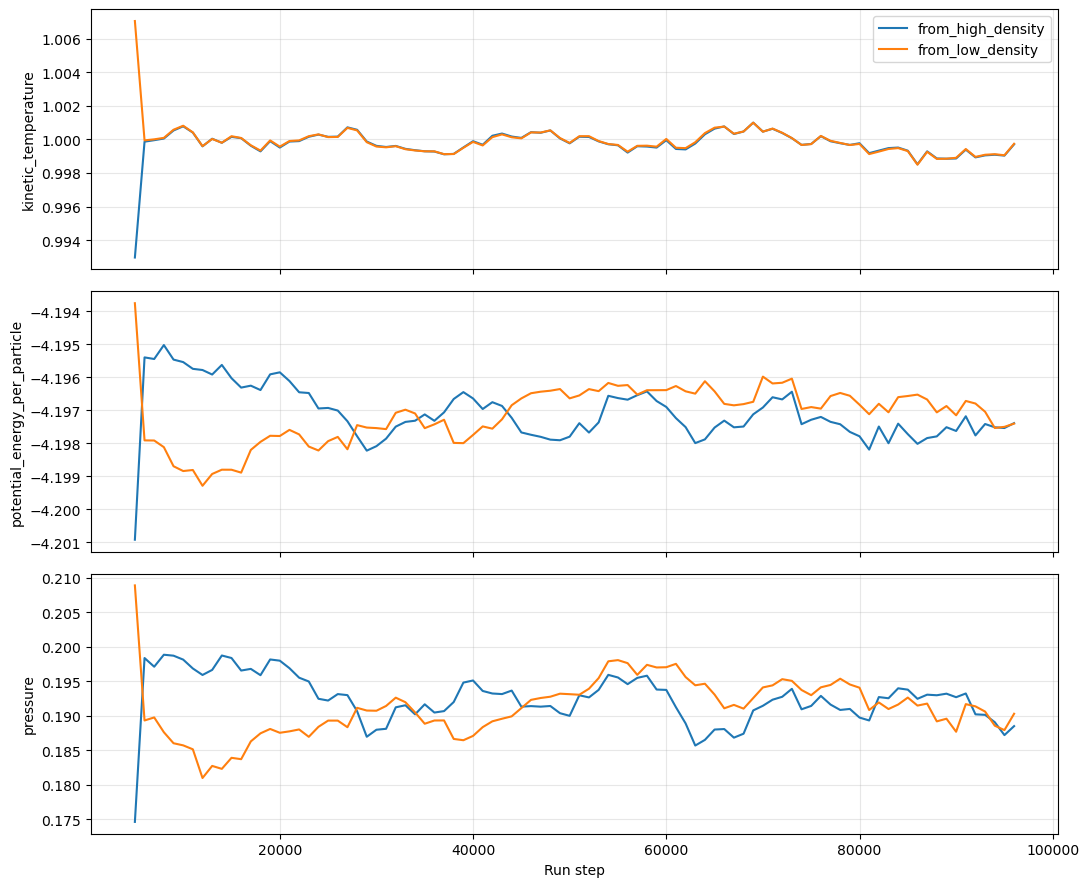

In [32]:
import matplotlib.pyplot as plt
from md_Helpers import open_run

quantities = [
    "kinetic_temperature",
    "potential_energy_per_particle",
    "pressure",
]

fig, axes = plt.subplots(
    len(quantities),
    1,
    figsize=(11, 9),
    sharex=True,
)

colors = {
    "from_high_density": "tab:blue",
    "from_low_density": "tab:orange",
}

for history, run_id in hold_results.items():
    logs = open_run(run_id).logs_dataframe()
    window = max(10, len(logs) // 30)

    for ax, quantity in zip(axes, quantities):
        ax.plot(
            logs["run_step"],
            logs[quantity].rolling(window, center=True).mean(),
            color=colors[history],
            label=history,
        )
        ax.set_ylabel(quantity)
        ax.grid(alpha=0.3)

axes[-1].set_xlabel("Run step")
axes[0].legend()
plt.tight_layout()
plt.show()

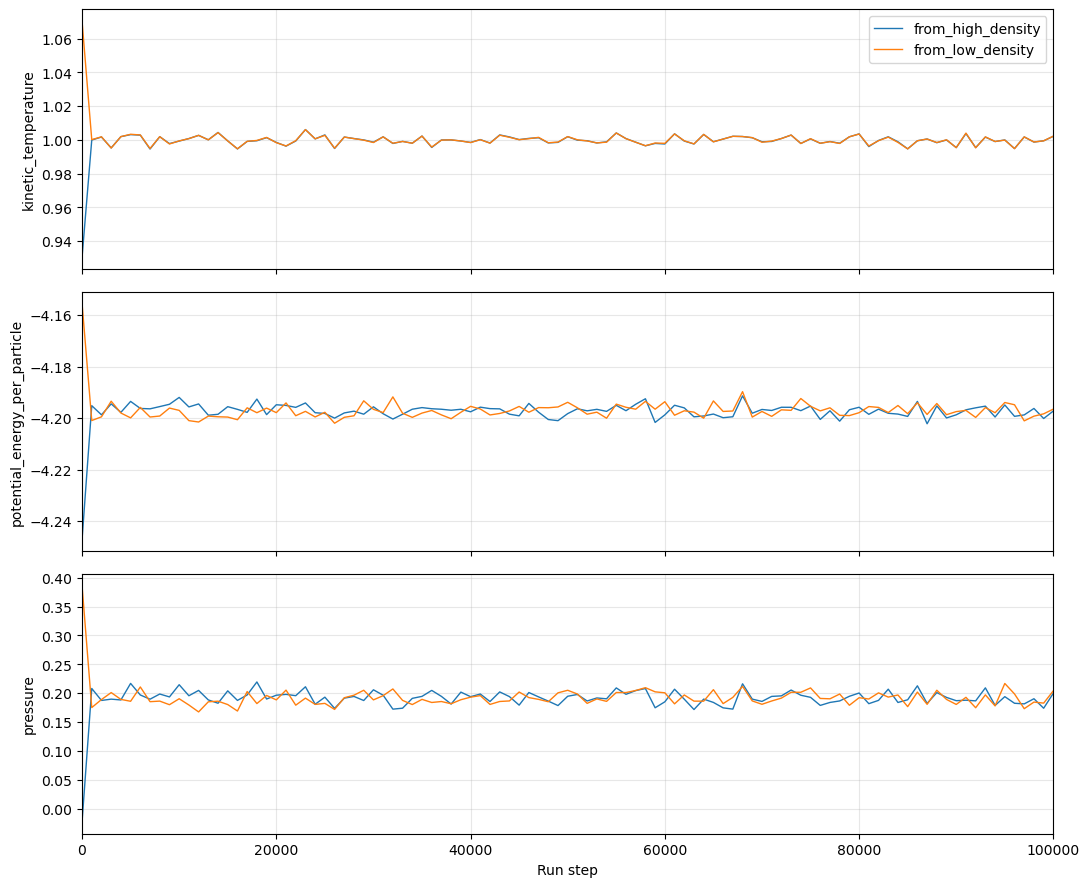

In [30]:
import matplotlib.pyplot as plt
from md_Helpers import open_run

max_run_step = 100_000  # Change as needed

quantities = [
    "kinetic_temperature",
    "potential_energy_per_particle",
    "pressure",
]

fig, axes = plt.subplots(
    len(quantities),
    1,
    figsize=(11, 9),
    sharex=True,
)

colors = {
    "from_high_density": "tab:blue",
    "from_low_density": "tab:orange",
}

for history, run_id in hold_results.items():
    logs = open_run(run_id).logs_dataframe()
    logs = logs.loc[logs["run_step"] <= max_run_step]

    for ax, quantity in zip(axes, quantities):
        ax.plot(
            logs["run_step"],
            logs[quantity],
            color=colors[history],
            linewidth=1.0,
            label=history,
        )

        ax.set_ylabel(quantity)
        ax.grid(alpha=0.3)

axes[-1].set_xlabel("Run step")
axes[-1].set_xlim(0, max_run_step)
axes[0].legend()

plt.tight_layout()
plt.show()